# XE9L Unused Algorithm Analysis

Analyze the 4 percussion/rhythm algorithms that are not referenced by regular programs:

| Algorithm | ROM Address | A-RAM Slot | Description |
|-----------|-------------|------------|-------------|
| ALG_871A  | 0x871A      | 0x00       | percussion/rhythm slot 0 |
| ALG_86DA  | 0x86DA      | 0x20       | percussion/rhythm slot 1 (used by drums) |
| ALG_3503  | 0x3503      | 0xC0       | percussion/rhythm slot 6 |
| ALG_9AFF  | 0x9AFF      | 0xE0       | percussion/rhythm slot 7 |

Note: Algorithm 0x86DA is used by the 33 drum sounds, so we have data to test with.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from sam8905_interpreter import (
    SAM8905Interpreter,
    plot_waveform,
    export_wav,
    print_state,
)
from sam8905_aram_decoder import decode_algorithm, analyze_dram_usage
from xe9l_programs import ALGORITHMS, DRUM_SOUNDS, DRUM_ALGORITHM

import importlib
import sam8905_interpreter
importlib.reload(sam8905_interpreter)

import xe9l_programs
importlib.reload(xe9l_programs)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Algorithm 871A (Slot 0x00 - Percussion/Rhythm 0)

Decode and analyze the first unused algorithm.

In [2]:
aram_871a = ALGORITHMS['871A']

print("Algorithm 871A - Percussion/Rhythm Slot 0")
print("=" * 60)
print(decode_algorithm(aram_871a))

print("\nD-RAM Usage:")
usage_871a = analyze_dram_usage(aram_871a)
for addr, counts in sorted(usage_871a.items()):
    print(f"  D[{addr:2d}]: read={counts['read']}, write={counts['write']}")

Algorithm 871A - Percussion/Rhythm Slot 0

PC00: 086F  RM 1, <WA, WPHI>
PC01: 00BF  RM 0, <WB>
PC02: 0ADF  RADD 1, <WM>
PC03: 113F  RM 2, <WA, WB, WSP> ***
PC04: 12DF  RADD 2, <WM>
PC05: 18BF  RM 3, <WB>
PC06: 13DF  RADD 2, <WM, WSP> ***
PC07: 7EFB  RSP, <clearB>
PC08: 687D  RM 13, <WA, WWF>
PC09: 70F7  RM 14, <WXY>
PC10: 78BD  RM 15, <WB, WWF>
PC11: 7CEF  RP, <WPHI>
PC12: 7BD7  RADD 15, <WM, WXY, WSP> ***
PC13: 4877  RM 9, <WA, WXY>
PC14: 7FFF  RSP, <WSP> ***
PC15: 7CBF  RP, <WB>
PC16: 70F7  RM 14, <WXY>
PC17: 50EF  RM 10, <WPHI>
PC18: 7CF7  RP, <WXY>
PC19: 7A7F  RADD, <WA>
PC20: 7CBF  RP, <WB>
PC21: 7A7F  RADD, <WA>
PC22: 58AF  RM 11, <WB, WPHI>
PC23: 62DF  RADD 12, <WM>
PC24: 403F  RM 8, <WA, WB>
PC25: 7A7F  RADD, <WA>
PC26: 38B7  RM 7, <WB, WXY>
PC27: 3BDF  RADD 7, <WM, WSP> ***
PC28: 7FFF  RSP, <WSP> ***
PC29: 7EFE  RSP, <WACC>
PC30: 7FFF  RSP, <WSP> ***
PC31: 7FFF  RSP, <WSP> ***

D-RAM Usage:
  D[ 0]: read=1, write=0
  D[ 1]: read=1, write=1
  D[ 2]: read=1, write=2
  D[ 3]: rea

## Algorithm 86DA (Slot 0x20 - Percussion/Rhythm 1 - DRUM SOUNDS)

This algorithm is used by all 33 drum sounds.

In [3]:
aram_86da = ALGORITHMS['86DA']

print("Algorithm 86DA - Percussion/Rhythm Slot 1 (Drum Sounds)")
print("=" * 60)
print(decode_algorithm(aram_86da))

print("\nD-RAM Usage:")
usage_86da = analyze_dram_usage(aram_86da)
for addr, counts in sorted(usage_86da.items()):
    print(f"  D[{addr:2d}]: read={counts['read']}, write={counts['write']}")

Algorithm 86DA - Percussion/Rhythm Slot 1 (Drum Sounds)

PC00: 01EF  RM 0, <WPHI, WSP> ***
PC01: 08FD  RM 1, <WWF>
PC02: 186F  RM 3, <WA, WPHI>
PC03: 10BF  RM 2, <WB>
PC04: 1ADF  RADD 3, <WM>
PC05: 013F  RM 0, <WA, WB, WSP> ***
PC06: 02DB  RADD 0, <WM, clearB>
PC07: 23DF  RADD 4, <WM, WSP> ***
PC08: 21F7  RM 4, <WXY, WSP> ***
PC09: 29EF  RM 5, <WPHI, WSP> ***
PC10: 30FD  RM 6, <WWF>
PC11: 406E  RM 8, <WA, WPHI, WACC>
PC12: 38BF  RM 7, <WB>
PC13: 42DF  RADD 8, <WM>
PC14: 293F  RM 5, <WA, WB, WSP> ***
PC15: 2ADB  RADD 5, <WM, clearB>
PC16: 4BDF  RADD 9, <WM, WSP> ***
PC17: 49F7  RM 9, <WXY, WSP> ***
PC18: 51EF  RM 10, <WPHI, WSP> ***
PC19: 58FD  RM 11, <WWF>
PC20: 686E  RM 13, <WA, WPHI, WACC>
PC21: 60BF  RM 12, <WB>
PC22: 6ADF  RADD 13, <WM>
PC23: 513F  RM 10, <WA, WB, WSP> ***
PC24: 52DB  RADD 10, <WM, clearB>
PC25: 73DF  RADD 14, <WM, WSP> ***
PC26: 71F7  RM 14, <WXY, WSP> ***
PC27: 7FFF  RSP, <WSP> ***
PC28: 7FFF  RSP, <WSP> ***
PC29: 7EFE  RSP, <WACC>
PC30: 7FFF  RSP, <WSP> ***
PC31

## Algorithm 3503 (Slot 0xC0 - Percussion/Rhythm 6)

In [4]:
aram_3503 = ALGORITHMS['3503']

print("Algorithm 3503 - Percussion/Rhythm Slot 6")
print("=" * 60)
print(decode_algorithm(aram_3503))

print("\nD-RAM Usage:")
usage_3503 = analyze_dram_usage(aram_3503)
for addr, counts in sorted(usage_3503.items()):
    print(f"  D[{addr:2d}]: read={counts['read']}, write={counts['write']}")

Algorithm 3503 - Percussion/Rhythm Slot 6

PC00: 79F7  RM 15, <WXY, WSP> ***
PC01: 48FD  RM 9, <WWF>
PC02: 186F  RM 3, <WA, WPHI>
PC03: 10BF  RM 2, <WB>
PC04: 1ADF  RADD 3, <WM>
PC05: 307F  RM 6, <WA>
PC06: 50F7  RM 10, <WXY>
PC07: 38AF  RM 7, <WB, WPHI>
PC08: 3ADF  RADD 7, <WM>
PC09: 7EFE  RSP, <WACC>
PC10: 007F  RM 0, <WA>
PC11: 50F7  RM 10, <WXY>
PC12: 40FD  RM 8, <WWF>
PC13: 08AF  RM 1, <WB, WPHI>
PC14: 0ADF  RADD 1, <WM>
PC15: 7EFE  RSP, <WACC>
PC16: 207F  RM 4, <WA>
PC17: 50F7  RM 10, <WXY>
PC18: 28AF  RM 5, <WB, WPHI>
PC19: 2ADF  RADD 5, <WM>
PC20: 7EFE  RSP, <WACC>
PC21: 587F  RM 11, <WA>
PC22: 50B7  RM 10, <WB, WXY>
PC23: 53DF  RADD 10, <WM, WSP> ***
PC24: 183F  RM 3, <WA, WB>
PC25: 7EFE  RSP, <WACC>
PC26: 7BEF  RADD, <WPHI, WSP> ***
PC27: 60B7  RM 12, <WB, WXY>
PC28: 687F  RM 13, <WA>
PC29: 63DE  RADD 12, <WM, WACC, WSP> ***
PC30: 7FFF  RSP, <WSP> ***
PC31: 7FFF  RSP, <WSP> ***

D-RAM Usage:
  D[ 0]: read=1, write=0
  D[ 1]: read=1, write=1
  D[ 2]: read=1, write=0
  D[ 3]: r

## Algorithm 9AFF (Slot 0xE0 - Percussion/Rhythm 7)

In [5]:
aram_9aff = ALGORITHMS['9AFF']

print("Algorithm 9AFF - Percussion/Rhythm Slot 7")
print("=" * 60)
print(decode_algorithm(aram_9aff))

print("\nD-RAM Usage:")
usage_9aff = analyze_dram_usage(aram_9aff)
for addr, counts in sorted(usage_9aff.items()):
    print(f"  D[{addr:2d}]: read={counts['read']}, write={counts['write']}")

Algorithm 9AFF - Percussion/Rhythm Slot 7

PC00: 00FD  RM 0, <WWF>
PC01: 386F  RM 7, <WA, WPHI>
PC02: 40F7  RM 8, <WXY>
PC03: 7EFB  RSP, <clearB>
PC04: 7EFB  RSP, <clearB>
PC05: 7FFB  RSP, <clearB, WSP> ***
PC06: 31AF  RM 6, <WB, WPHI, WSP> ***
PC07: 3A0F  RADD 7, <WA, WB, WM, WPHI>
PC08: 7FFF  RSP, <WSP> ***
PC09: 08F7  RM 1, <WXY>
PC10: 7A2F  RADD, <WA, WB, WPHI>
PC11: 4CDF  RP 9, <WM>
PC12: 10F7  RM 2, <WXY>
PC13: 7A2F  RADD, <WA, WB, WPHI>
PC14: 54DF  RP 10, <WM>
PC15: 18F7  RM 3, <WXY>
PC16: 7A2F  RADD, <WA, WB, WPHI>
PC17: 5CDF  RP 11, <WM>
PC18: 20F7  RM 4, <WXY>
PC19: 7AEF  RADD, <WPHI>
PC20: 7C7F  RP, <WA>
PC21: 28F7  RM 5, <WXY>
PC22: 48BF  RM 9, <WB>
PC23: 7A7F  RADD, <WA>
PC24: 7CBF  RP, <WB>
PC25: 7A7F  RADD, <WA>
PC26: 50BF  RM 10, <WB>
PC27: 7A7F  RADD, <WA>
PC28: 58BF  RM 11, <WB>
PC29: 42DF  RADD 8, <WM>
PC30: 7FFF  RSP, <WSP> ***
PC31: 7FFF  RSP, <WSP> ***

D-RAM Usage:
  D[ 0]: read=1, write=0
  D[ 1]: read=1, write=0
  D[ 2]: read=1, write=0
  D[ 3]: read=1, write=0

## Algorithm Comparison

Compare D-RAM usage patterns across all 4 algorithms.

In [6]:
algorithms = {
    '871A': (aram_871a, usage_871a),
    '86DA': (aram_86da, usage_86da),
    '3503': (aram_3503, usage_3503),
    '9AFF': (aram_9aff, usage_9aff),
}

print("D-RAM Usage Comparison")
print("=" * 80)
print(f"{'Word':<6} {'871A':<15} {'86DA':<15} {'3503':<15} {'9AFF':<15}")
print("-" * 80)

all_words = set()
for name, (aram, usage) in algorithms.items():
    all_words.update(usage.keys())

for word in sorted(all_words):
    row = f"D[{word:2d}]  "
    for name in ['871A', '86DA', '3503', '9AFF']:
        aram, usage = algorithms[name]
        if word in usage:
            r, w = usage[word]['read'], usage[word]['write']
            row += f"R={r} W={w}       "
        else:
            row += "---            "
    print(row)

# Count special operations
print("\n" + "=" * 80)
print("Operation Counts")
print("-" * 80)

for name, (aram, usage) in algorithms.items():
    # Count WACC operations
    wacc_count = sum(1 for w in aram if (w & 0x0008) and not (w & 0x4000))
    # Count WWF operations
    wwf_count = sum(1 for w in aram if (w & 0x0001) and not (w & 0x4000))
    # Count RSP operations
    rsp_count = sum(1 for w in aram if (w & 0x7800) == 0x7800)
    # Count RADD operations
    radd_count = sum(1 for w in aram if (w & 0x4000))
    
    print(f"{name}: WACC={wacc_count}, WWF={wwf_count}, RSP={rsp_count}, RADD={radd_count}")

D-RAM Usage Comparison
Word   871A            86DA            3503            9AFF           
--------------------------------------------------------------------------------
D[ 0]  R=1 W=0       R=2 W=1       R=1 W=0       R=1 W=0       
D[ 1]  R=1 W=1       R=1 W=0       R=1 W=1       R=1 W=0       
D[ 2]  R=1 W=2       R=1 W=0       R=1 W=0       R=1 W=0       
D[ 3]  R=1 W=0       R=1 W=1       R=2 W=1       R=1 W=0       
D[ 4]  ---            R=1 W=1       R=1 W=0       R=1 W=0       
D[ 5]  ---            R=2 W=1       R=1 W=1       R=1 W=0       
D[ 6]  ---            R=1 W=0       R=1 W=0       R=1 W=0       
D[ 7]  R=1 W=1       R=1 W=0       R=1 W=1       R=1 W=1       
D[ 8]  R=1 W=0       R=1 W=1       R=1 W=0       R=1 W=1       
D[ 9]  R=1 W=0       R=1 W=1       R=1 W=0       R=1 W=1       
D[10]  R=1 W=0       R=2 W=1       R=4 W=1       R=1 W=1       
D[11]  R=1 W=0       R=1 W=0       R=1 W=0       R=1 W=1       
D[12]  R=0 W=1       R=1 W=0       R=1 W=1       ---  

## Drum Sounds List

All 33 drum sounds use algorithm 86DA.

In [7]:
print(f"Drum sounds using algorithm 0x{DRUM_ALGORITHM:04X} ({len(DRUM_SOUNDS)} total):\n")
for i, drum in enumerate(DRUM_SOUNDS):
    print(f"{i:2d}. [{drum['idx']:2d}] {drum['name']:<10} addr=0x{drum['addr']:04X} "
          f"flags=0x{drum['flags']:02X} slots={drum['slot_count']}")

Drum sounds using algorithm 0x86DA (33 total):

 0. [ 0] GATESD     addr=0x8760 flags=0x11 slots=1
 1. [ 1] MONDO      addr=0x878E flags=0x11 slots=1
 2. [ 2] KICK2      addr=0x87BC flags=0x11 slots=1
 3. [ 3] KICK1      addr=0x87EA flags=0x11 slots=1
 4. [ 4] STICK      addr=0x881B flags=0x11 slots=1
 5. [ 5] SNARE1     addr=0x884C flags=0x11 slots=1
 6. [ 6] CLAPS      addr=0x887D flags=0x11 slots=1
 7. [ 7] SNARE2     addr=0x88AE flags=0x11 slots=1
 8. [ 8] CLOHH      addr=0x88DF flags=0x11 slots=1
 9. [ 9] PEDHH      addr=0x8910 flags=0x11 slots=1
10. [10] OPHH       addr=0x8941 flags=0x11 slots=1
11. [11] LOBG       addr=0x8972 flags=0x11 slots=1
12. [12] SHGUIRO    addr=0x89A0 flags=0x11 slots=1
13. [13] HIWB       addr=0x89CE flags=0x11 slots=1
14. [14] LOGUIRO    addr=0x89FC flags=0x11 slots=1
15. [15] BRTAP      addr=0x8A2A flags=0x11 slots=1
16. [16] BELL       addr=0x8A5B flags=0x11 slots=1
17. [17] BRSLAP     addr=0x8A8C flags=0x11 slots=1
18. [18] CAB        addr=0x8ABD fl

## Test Drum Sound with Algorithm 86DA

Load a drum sound and run it through the algorithm.

In [9]:
# Select drum by index (0-32)
DRUM_INDEX = 3  # KICK1

drum = DRUM_SOUNDS[DRUM_INDEX]
print(f"Selected drum: {drum['name']} (index {drum['idx']})")
print(f"  Address: 0x{drum['addr']:04X}")
print(f"  Flags: 0x{drum['flags']:02X}, Slots: {drum['slot_count']}")
print(f"  D-RAM entry0: word=0x{drum['dram_entry0']['word']:04X}")

print(f"\n  D-RAM stream ({len(drum['dram_stream'])} bytes):")
stream_hex = ' '.join(f"{b:02X}" for b in drum['dram_stream'])
print(f"    {stream_hex}")

print(f"\n  D-RAM init (non-zero):")
for i, v in enumerate(drum['dram_init']):
    if v != 0:
        print(f"    D[{i:2d}] = 0x{v:05X}")

print(f"\n  Pitch params: {drum['pitch_params']}")
print(f"  Amp params: {drum['amp_params']}")
print(f"  Waveform words: {drum['waveform_words']}")

Selected drum: KICK1 (index 3)
  Address: 0x87EA
  Flags: 0x11, Slots: 1
  D-RAM entry0: word=0x0000

  D-RAM stream (22 bytes):
    18 6E C7 06 18 00 C0 01 08 00 04 C8 00 00 00 00 00 00 00 00 00 83

  D-RAM init (non-zero):
    D[ 0] = 0x00018
    D[ 1] = 0x00018
    D[ 4] = 0x00003
    D[ 6] = 0x20000
    D[11] = 0x20000

  Pitch params: {'note_offset': 4, 'fine_tune': 0, 'vel_sens': 0}
  Amp params: {'level': 0, 'amp': 127, 'vel_sens': 0, 'env_ctrl': 0}
  Waveform words: [1, 6, 11]


In [10]:
# Create interpreter and load algorithm 86DA
sam = SAM8905Interpreter()
sam.load_aram(aram_86da, offset=0)  # Load as algorithm 0

# Load drum's initial D-RAM configuration
dram_slot0 = drum['dram_init'].copy()

# Override test parameters
TEST_FREQ = 220  # Hz (lower for percussion)
TEST_AMP = 0x07FF  # Max amplitude
MIX_L, MIX_R = 7, 7  # Full pan

# Calculate phase increment
phase_inc = int(4096 * TEST_FREQ / 44100)

# Examine algorithm to find phase increment word
# For 86DA, D[0] and D[1] seem to be phase-related based on the decode
dram_slot0[0] = phase_inc << 7

# Set amplitude in words that seem to be amplitude-related
amp_value = (TEST_AMP << 7) | (MIX_L << 3) | MIX_R
# Based on D-RAM usage, words 4, 8, 12 are written to - these might be accumulators
# Words 3, 5, 7, 9, 11, 13 are read/written - these might be amplitude
if dram_slot0[3] == 0:
    dram_slot0[3] = amp_value
if dram_slot0[5] == 0:
    dram_slot0[5] = amp_value

sam.load_dram(0, dram_slot0)

print(f"Loaded {drum['name']} D-RAM configuration:")
print(f"  Phase increment: {phase_inc} (0x{phase_inc:03X}) for {TEST_FREQ}Hz")
print(f"  Test amplitude: 0x{TEST_AMP:03X}")
print(f"\nD-RAM state (non-zero):")
for i, v in enumerate(dram_slot0):
    if v != 0:
        print(f"  D[{i:2d}] = 0x{v:05X}")

Loaded KICK1 D-RAM configuration:
  Phase increment: 20 (0x014) for 220Hz
  Test amplitude: 0x7FF

D-RAM state (non-zero):
  D[ 0] = 0x00A00
  D[ 1] = 0x00018
  D[ 3] = 0x3FFBF
  D[ 4] = 0x00003
  D[ 5] = 0x3FFBF
  D[ 6] = 0x20000
  D[11] = 0x20000


Generated 2000 samples
L range: [0, 0]
R range: [0, 0]


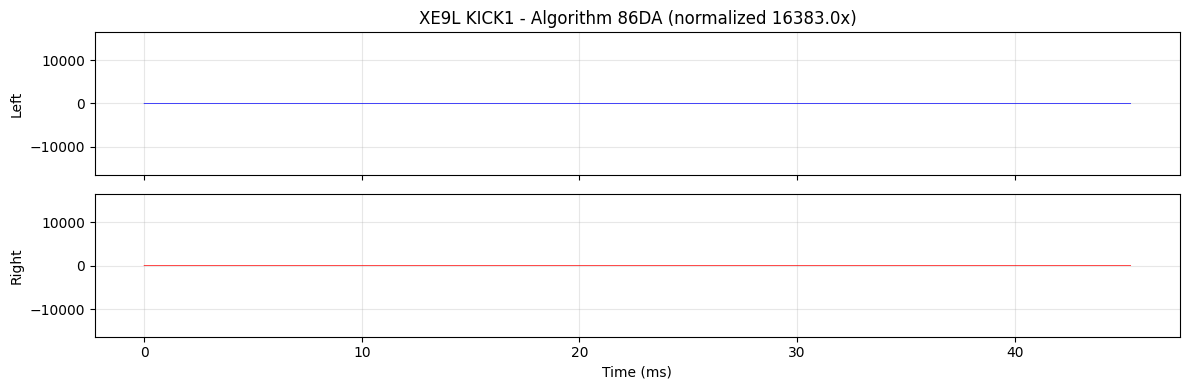

In [11]:
# Generate samples
samples = sam.run(2000, active_slots=[0])

print(f"Generated {len(samples)} samples")
print(f"L range: [{samples[:, 0].min()}, {samples[:, 0].max()}]")
print(f"R range: [{samples[:, 1].min()}, {samples[:, 1].max()}]")

# Plot waveform
plot_waveform(samples, title=f"XE9L {drum['name']} - Algorithm 86DA", normalize=True)
plt.show()

In [12]:
# Reset and enable tracing
sam.reset()
sam.load_aram(aram_86da, offset=0)
sam.load_dram(0, dram_slot0)

sam.trace_enabled = True
sam.trace_output = []

# Run 2 frames to see instruction flow
samples = sam.run(2, active_slots=[0])

print("Instruction trace (2 frames) for algorithm 86DA:")
for line in sam.trace_output:
    print(line)

Instruction trace (2 frames) for algorithm 86DA:
S00 PC00: 01EF  RM 0, <WPHI, WSP>  -> phi=0x00014, wf=0x00100
S00 PC01: 08FD  RM 1, <WWF>  -> wf=0x00000
S00 PC02: 186F  RM 3, <WA, WPHI>  -> a=0x3FFBF, phi=0x007FF
S00 PC03: 10BF  RM 2, <WB>  -> b=0x00000
S00 PC04: 1ADF  RADD 3, <WM>
S00 PC05: 013F  RM 0, <WA, WB, WSP>  -> a=0x00000, b=0x00A00
S00 PC06: 02DB  RADD 0, <WM, clearB>  -> b=0x00000
S00 PC07: 23DF  RADD 4, <WM, WSP>
S00 PC08: 21F7  RM 4, <WXY, WSP>  -> x=0x00000, y=0x00000, mul=0x00000, mix_l=0x00000, mix_r=0x00003
S00 PC09: 29EF  RM 5, <WPHI, WSP>  -> phi=0x007FF, wf=0x00100
S00 PC10: 30FD  RM 6, <WWF>  -> wf=0x00100
S00 PC11: 406E  RM 8, <WA, WPHI, WACC>  -> a=0x00000, phi=0x00000, l_acc=0x00000, r_acc=0x00000
S00 PC12: 38BF  RM 7, <WB>  -> b=0x00000
S00 PC13: 42DF  RADD 8, <WM>
S00 PC14: 293F  RM 5, <WA, WB, WSP>  -> a=0x00000, b=0x3FFBF
S00 PC15: 2ADB  RADD 5, <WM, clearB>  -> b=0x00000
S00 PC16: 4BDF  RADD 9, <WM, WSP>
S00 PC17: 49F7  RM 9, <WXY, WSP>  -> x=0x00001, y=0x

## Algorithm Structure Analysis

Analyze each algorithm's signal flow based on instruction patterns.

In [8]:
def analyze_algorithm_structure(name, aram):
    """Analyze algorithm structure and identify key patterns."""
    print(f"\n{'=' * 60}")
    print(f"Algorithm {name} Structure Analysis")
    print(f"{'=' * 60}")
    
    # Find WACC (output accumulate) operations
    wacc_pcs = []
    for pc, word in enumerate(aram):
        if (word & 0x0008) and not (word & 0x4000):  # WACC bit set, not RADD
            wacc_pcs.append(pc)
    print(f"\nWACC (output) at PCs: {wacc_pcs}")
    
    # Find WWF (waveform fetch) operations
    wwf_pcs = []
    for pc, word in enumerate(aram):
        if (word & 0x0001) and not (word & 0x4000):  # WWF bit set, not RADD
            wwf_pcs.append(pc)
    print(f"WWF (waveform) at PCs: {wwf_pcs}")
    
    # Find phase operations (WPHI bit)
    wphi_pcs = []
    for pc, word in enumerate(aram):
        if (word & 0x0020) and not (word & 0x4000):  # WPHI bit set, not RADD
            wphi_pcs.append(pc)
    print(f"WPHI (phase) at PCs: {wphi_pcs}")
    
    # Find WSP (set pan/mix) operations
    wsp_pcs = []
    for pc, word in enumerate(aram):
        if (word & 0x0004) and not (word & 0x4000):  # WSP bit set, not RADD
            wsp_pcs.append(pc)
    print(f"WSP (set pan) at PCs: {wsp_pcs}")
    
    # Find RADD (D-RAM accumulate) operations
    radd_ops = []
    for pc, word in enumerate(aram):
        if (word & 0x4000):  # RADD bit set
            addr = (word >> 8) & 0x0F
            radd_ops.append((pc, addr))
    print(f"RADD (D-RAM acc) operations: {radd_ops}")
    
    # Identify oscillator count based on WWF usage
    print(f"\nOscillator estimate: {len(wwf_pcs)} waveform fetches")
    
    # Identify output voices based on WACC count
    print(f"Output points: {len(wacc_pcs)} accumulates to output")

# Analyze all 4 algorithms
for name, (aram, _) in algorithms.items():
    analyze_algorithm_structure(name, aram)


Algorithm 871A Structure Analysis

WACC (output) at PCs: [0, 1, 2, 3, 4, 5, 6, 27]
WWF (waveform) at PCs: [0, 1, 2, 3, 4, 5, 6, 26, 27]
WPHI (phase) at PCs: [0, 1, 3, 5, 26]
WSP (set pan) at PCs: [0, 1, 2, 3, 4, 5, 6, 26, 27]
RADD (D-RAM acc) operations: [(7, 14), (8, 8), (9, 0), (10, 8), (11, 12), (12, 11), (13, 8), (14, 15), (15, 12), (16, 0), (17, 0), (18, 12), (19, 10), (20, 12), (21, 10), (22, 8), (23, 2), (24, 0), (25, 10), (28, 15), (29, 14), (30, 15), (31, 15)]

Oscillator estimate: 9 waveform fetches
Output points: 8 accumulates to output

Algorithm 86DA Structure Analysis

WACC (output) at PCs: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 14, 15]
WWF (waveform) at PCs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 15]
WPHI (phase) at PCs: [0, 1, 2, 3, 5, 8, 9, 10, 12, 14]
WSP (set pan) at PCs: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 14]
RADD (D-RAM acc) operations: [(11, 0), (13, 2), (16, 11), (17, 9), (18, 1), (19, 8), (20, 8), (21, 0), (22, 10), (23, 1), (24, 2), (25, 3), (26, 1), (27, 15

## Notes and Findings

### Algorithm Structure Summary

| Algorithm | Slot | WACC Points | WWF Points | Description |
|-----------|------|-------------|------------|-------------|
| 871A | 0x00 | 8 | 9 | Complex multi-oscillator structure |
| 86DA | 0x20 | 2 (PC11, PC20) + final | 3 | 3-stage sample playback for drums |
| 3503 | 0xC0 | 5 (PC09, PC15, PC20, PC25, PC29) | 2 | Multi-stage rhythm generator |
| 9AFF | 0xE0 | 1 (final only) | 1 | Mixer/effects algorithm |

### Algorithm 86DA Structure (Drum Sounds)

The drum algorithm has 3 parallel stages for sample playback:
- **Stage 1** (D[0-4]): Phase in D[0], waveform via D[1], accumulate at PC11
- **Stage 2** (D[5-9]): Phase in D[5], waveform via D[6], accumulate at PC20  
- **Stage 3** (D[10-14]): Phase in D[10], waveform via D[11], final mixing

Each stage reads from different waveform ROM addresses for multi-sample drums.

### Why Drum Simulation Shows Zero Output

The drums are designed for **sample playback from waveform ROM**, not internal sine generation:
1. WWF at PC01 reads D[1]=0x18, which is a ROM address, not internal sine (0x20000)
2. The actual audio data comes from external waveform ROM samples
3. D[8] and D[13] (amplitude words read at WACC points) start at zero

To properly simulate drum sounds, we would need:
- Actual waveform ROM data from the XE9L hardware
- Proper sample address setup in D-RAM
- Understanding of the sample format and loop points

### Algorithm 871A vs 86DA Comparison

**871A** (Percussion Slot 0):
- More complex D-RAM usage (0-15)
- Multiple filter/accumulator stages
- Appears to be for pitched percussion or melodic content

**86DA** (Percussion Slot 1 - Drums):  
- Optimized for 3 simultaneous sample playback channels
- Simple amplitude envelope per channel
- Minimal filtering, focuses on sample-based output

### Algorithms 3503 and 9AFF

**3503** (Slot 0xC0):
- 5 WACC points suggest additive mixing of multiple sources
- Reads D[10] 4 times - likely a shared modulation source
- Could be rhythm pattern generator with multiple concurrent sounds

**9AFF** (Slot 0xE0):
- Multiple clearB operations reset B register frequently
- Many RADD operations without WACC - internal processing
- Likely a mixer/effects algorithm that combines other slots